# Support Vector Machine (SVM) — Alzheimer's Prediction

This notebook follows the same pipeline used in the other model notebooks: load data, preprocess, train several SVM configurations, evaluate and visualize results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset (notebooks live in ml/notebooks so path goes up to ml/datasets)
df = pd.read_csv('../datasets/alzheimers_disease_data.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid


In [3]:
# Basic cleaning / feature/target split
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])
X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train positive rate: {y_train.mean()*100:.1f}%')
print(f'Test positive rate:  {y_test.mean()*100:.1f}%')

Train size: 1719 | Test size: 430
Train positive rate: 35.4%
Test positive rate:  35.3%


In [4]:
# Define several SVM configurations to compare
configs = {
    "Config 1\n(Linear C=1)": SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    "Config 2\n(Linear C=0.1)": SVC(kernel='linear', C=0.1, probability=True, random_state=42),
    "Config 3\n(RBF default)": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    "Config 4\n(RBF C=10)": SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42),
    "Config 5\n(Poly degree=3)": SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42),
    "Config 6\n(Balanced class)": SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42)
}

In [5]:
# Train each configuration using a simple pipeline (scaling + SVC)
results = []

for name, svc in configs.items():
    print(f' Training {name}')
    pipe = Pipeline([('scaler', StandardScaler()), ('svc', svc)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    # predict_proba requires probability=True in SVC
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']

    results.append({
        'Config': name,
        'Kernel': svc.kernel,
        'C': getattr(svc, 'C', None),
        'Degree': getattr(svc, 'degree', None),
        'Accuracy': round(acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4),
        '_model': pipe,
        '_y_pred': y_pred,
        '_y_prob': y_prob
    })

results_df = pd.DataFrame(results)
display(results_df.drop(columns=['_model','_y_pred','_y_prob']))

 Training Config 1
(Linear C=1)
 Training Config 2
(Linear C=0.1)
 Training Config 3
(RBF default)
 Training Config 4
(RBF C=10)
 Training Config 5
(Poly degree=3)
 Training Config 6
(Balanced class)


,Config,Kernel,C,Degree,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Config 1\n(Linear C=1),linear,1.0,3,0.8279,0.7600,0.7500,0.7550,0.8838
1,Config 2\n(Linear C=0.1),linear,0.1,3,0.8233,0.7468,0.7566,0.7516,0.8832
2,Config 3\n(RBF default),rbf,1.0,3,0.8349,0.7914,0.7237,0.7560,0.8963
3,Config 4\n(RBF C=10),rbf,10.0,3,0.8302,0.7762,0.7303,0.7525,0.8939
4,Config 5\n(Poly degree=3),poly,1.0,3,0.8116,0.7983,0.6250,0.7011,0.8719
5,Config 6\n(Balanced class),rbf,1.0,3,0.8419,0.7442,0.8421,0.7901,0.8974


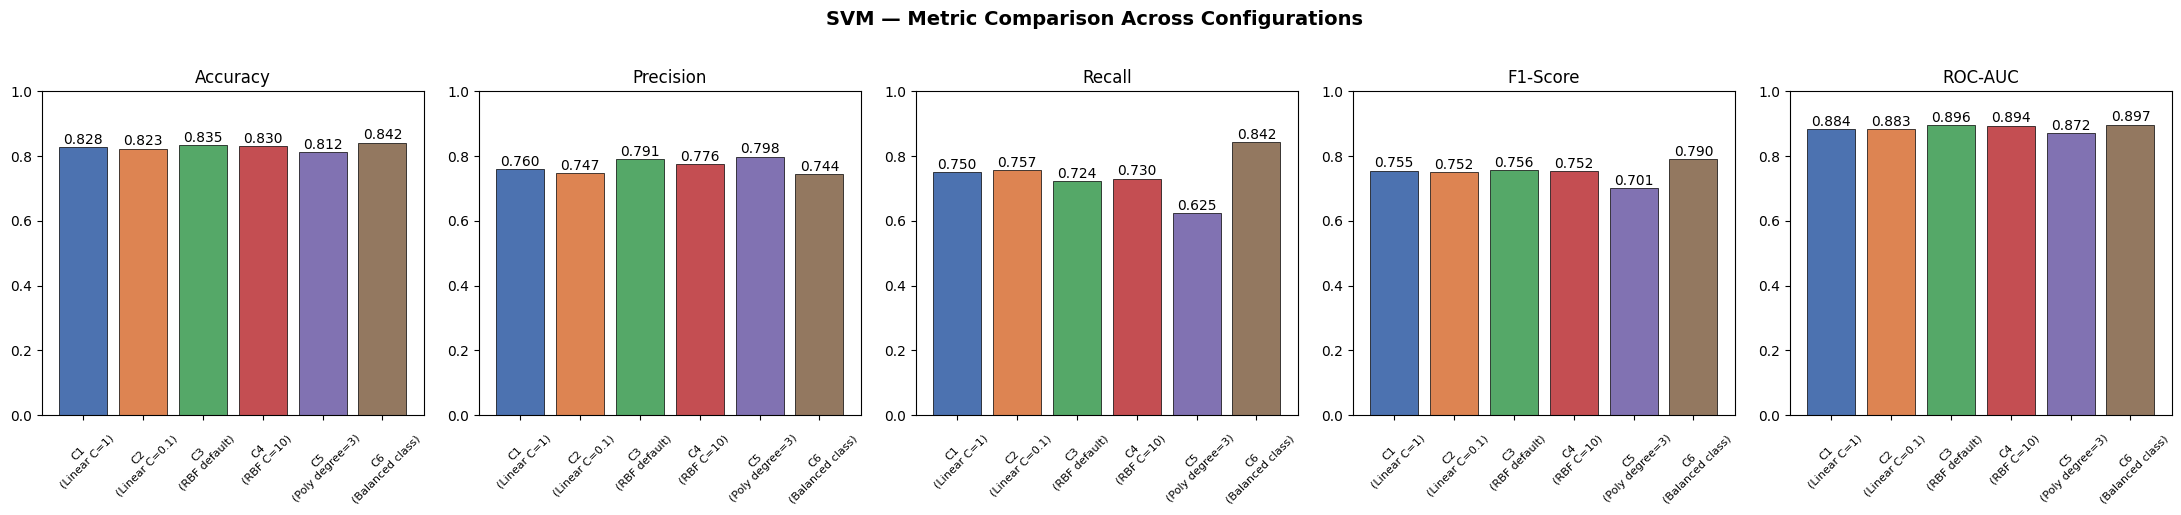

In [6]:
# Metric comparison plots
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
config_labels = [r['Config'].replace('Config ','C') for r in results]
fig, axes = plt.subplots(1, len(metrics), figsize=(22,5))
fig.suptitle('SVM — Metric Comparison Across Configurations', fontsize=14, fontweight='bold', y=1.02)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
for i, metric in enumerate(metrics):
    vals = [r[metric] for r in results]
    bars = axes[i].bar(config_labels, vals, color=colors[:len(vals)], edgecolor='black', linewidth=0.5)
    axes[i].set_title(metric)
    axes[i].set_ylim(0,1)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.show()

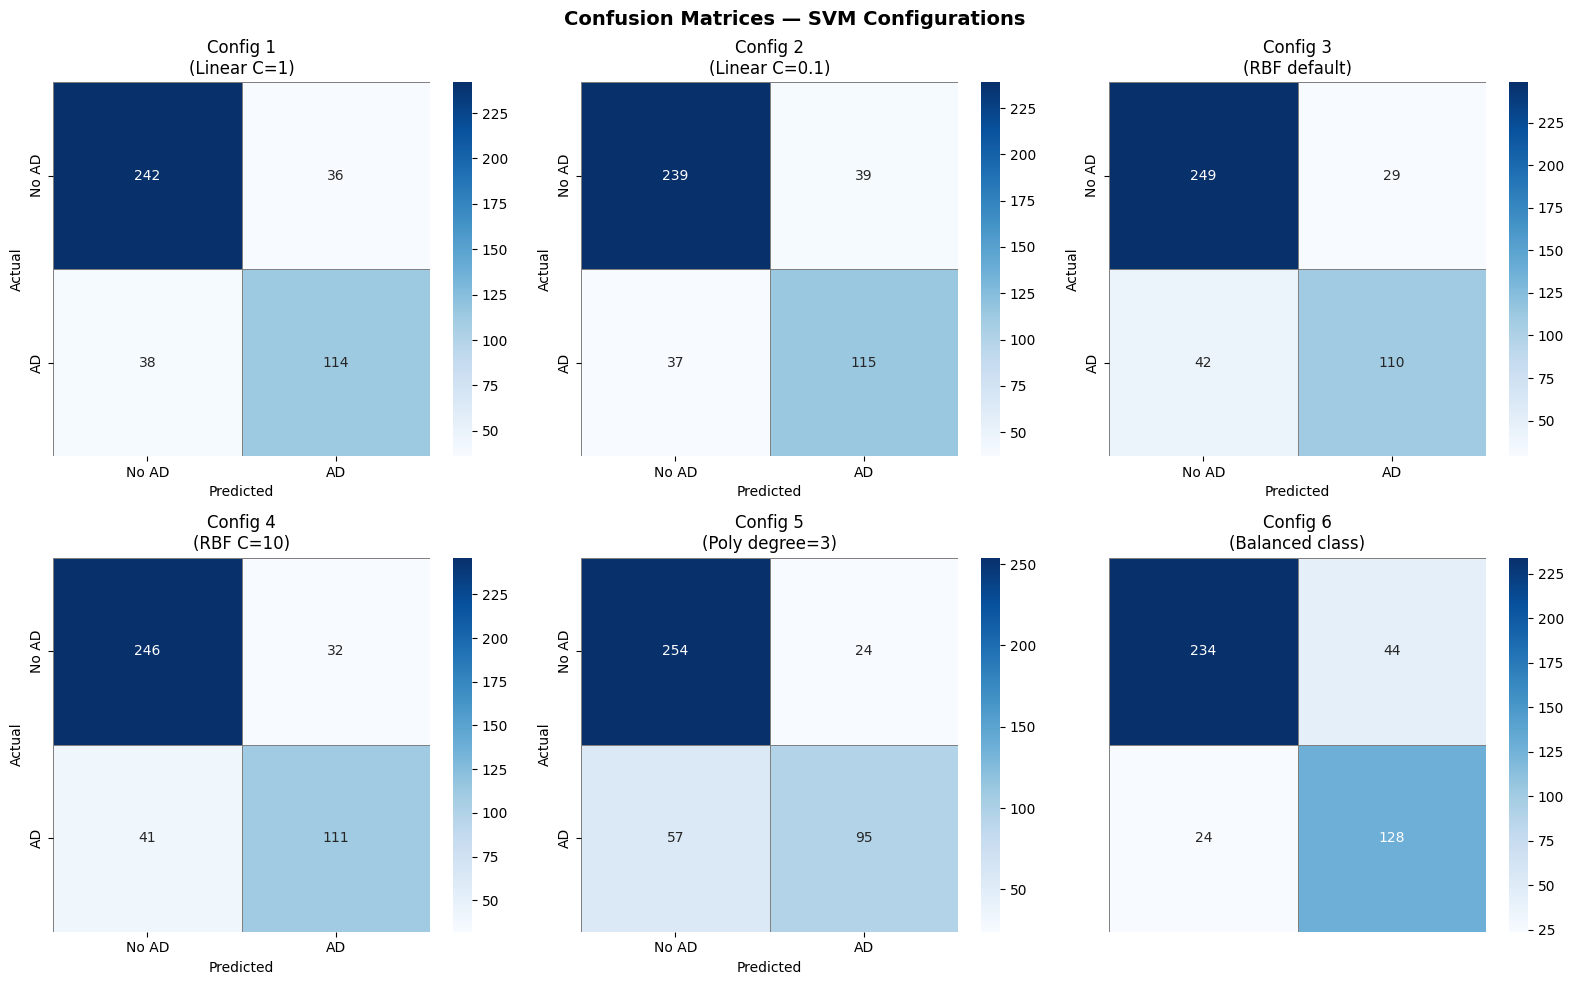

In [14]:
# Confusion matrices
fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()
for i, r in enumerate(results):
    cm = confusion_matrix(y_test, r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=['No AD','AD'], yticklabels=['No AD','AD'], linewidths=0.5, linecolor='gray')
    axes[i].set_title(r['Config'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — SVM Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    "../evaluation/confusion_matrices/svm_confusion.png",
    bbox_inches="tight"
)
plt.show()

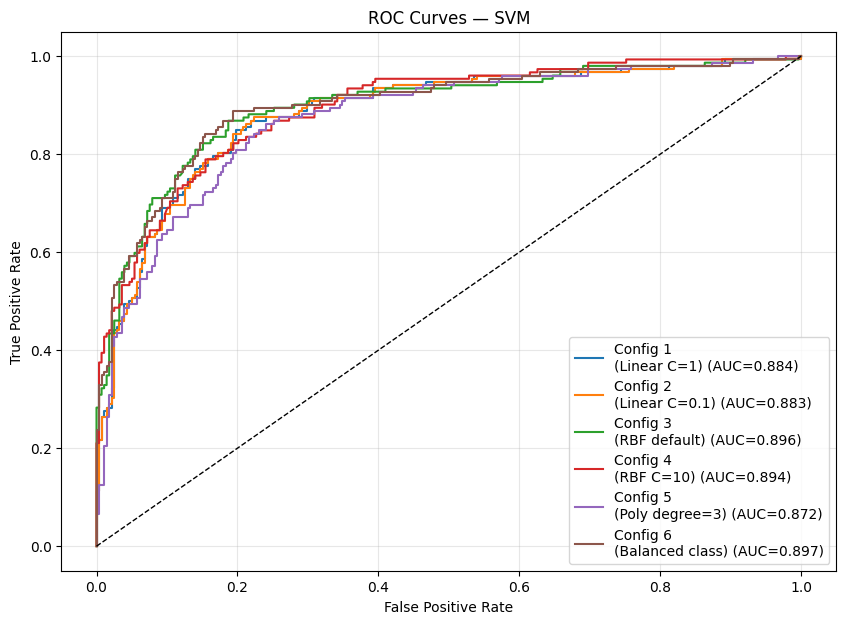

In [15]:
# ROC curves
plt.figure(figsize=(10,7))
for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r['_y_prob'])
    plt.plot(fpr, tpr, label=f"{r['Config']} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — SVM')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(
    "../evaluation/roc_curves/svm_roc.png",
    bbox_inches="tight"
)

plt.show()

In [9]:
# Summarize best model and attempt to show linear coefficients when available
best = max(results, key=lambda r: r['ROC-AUC'])
print(f"Best Config: {best['Config']}  |  ROC-AUC: {best['ROC-AUC']}")
model_best = best['_model']
svc_step = model_best.named_steps['svc'] if hasattr(model_best, 'named_steps') else model_best
if getattr(svc_step, 'kernel', None) == 'linear' and hasattr(svc_step, 'coef_'):
    coef = svc_step.coef_[0]
    feat_names = X.columns.tolist()
    coef_df = pd.DataFrame({'Feature': feat_names, 'Coefficient': coef})
    coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('AbsCoef', ascending=False).head(15)
    plt.figure(figsize=(10,6))
    colors = ['#C44E52' if c>0 else '#4C72B0' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
    plt.axvline(0, color='black')
    plt.gca().invert_yaxis()
    plt.title(f'Top 15 Feature Coefficients — {best[Config]}')
    plt.tight_layout()
    plt.show()
else:
    print('Best SVM kernel is not linear or coefficients not available; skipping coef plot.')

Best Config: Config 6
(Balanced class)  |  ROC-AUC: 0.8974
Best SVM kernel is not linear or coefficients not available; skipping coef plot.


In [10]:
# Final ranked summary
print('='*75)
print('FINAL SUMMARY — SVM CONFIGURATIONS')
print('='*75)
ranked = results_df.drop(columns=['_model','_y_pred','_y_prob']).sort_values('ROC-AUC', ascending=False)
print(ranked.to_string(index=False))
print(' Best by ROC-AUC :', ranked.iloc[0]['Config'])
print(' Best by Accuracy :', ranked.loc[ ranked['Accuracy'].idxmax(), 'Config' ])

FINAL SUMMARY — SVM CONFIGURATIONS
                    Config Kernel    C  Degree  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Config 6\n(Balanced class)    rbf  1.0       3    0.8419     0.7442  0.8421    0.7901   0.8974
   Config 3\n(RBF default)    rbf  1.0       3    0.8349     0.7914  0.7237    0.7560   0.8963
      Config 4\n(RBF C=10)    rbf 10.0       3    0.8302     0.7762  0.7303    0.7525   0.8939
    Config 1\n(Linear C=1) linear  1.0       3    0.8279     0.7600  0.7500    0.7550   0.8838
  Config 2\n(Linear C=0.1) linear  0.1       3    0.8233     0.7468  0.7566    0.7516   0.8832
 Config 5\n(Poly degree=3)   poly  1.0       3    0.8116     0.7983  0.6250    0.7011   0.8719
 Best by ROC-AUC : Config 6
(Balanced class)
 Best by Accuracy : Config 6
(Balanced class)


In [13]:
from joblib import dump

dump(model_best ,'../trained_models/svm.pkl')

['../trained_models/svm.pkl']